# Importing libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# load the dataset


In [2]:
#load the dataset
df=pd.read_csv(r"C:\Users\harsh\Documents\Data Analytics\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.sample(5)#randomly take any 5 values 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,0,0,248747,13.0000,NaN,S
336,337,0,1,"Pears, Mr. Thomas Clinton",male,29.0,1,0,113776,66.6000,C2,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0000,B94,S
455,456,1,3,"Jalsevac, Mr. Ivan",male,29.0,0,0,349240,7.8958,NaN,C
677,678,1,3,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# shapes and columns


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [8]:
df.shape

(891, 12)

In [8]:
columns=df.columns
print("\nColumn names:")
print(columns)


Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [9]:
print(f"column and datatype: ")
print(df.dtypes)

column and datatype: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


# check the total number of missing values


In [10]:
df.isnull().sum().sort_values(ascending=False).to_frame('missing_count')

,missing_count
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


In [11]:
display((df.isnull().mean() * 100).round(2).sort_values(ascending=False).to_frame('missing_percent'))

,missing_percent
Cabin,77.10
Age,19.87
Embarked,0.22
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
SibSp,0.00
Parch,0.00


# Numeric and Categorical summary


In [12]:
print("\nNumeric summary:")
display(df.describe().T)



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [16]:
print("Categorical summary:")
display(df.select_dtypes(include=['object','category']).describe().T)


Categorical summary:


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


# Univariate Classes


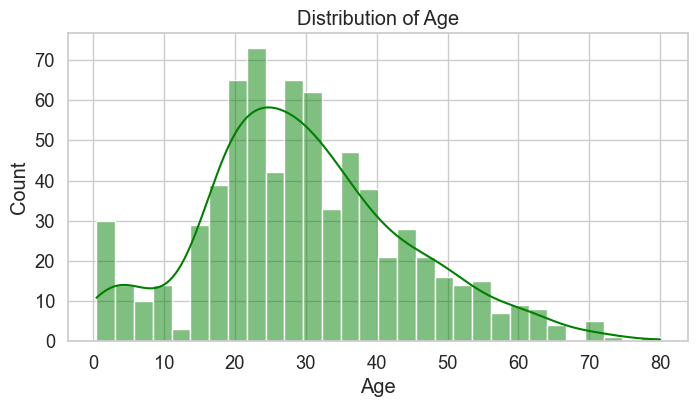

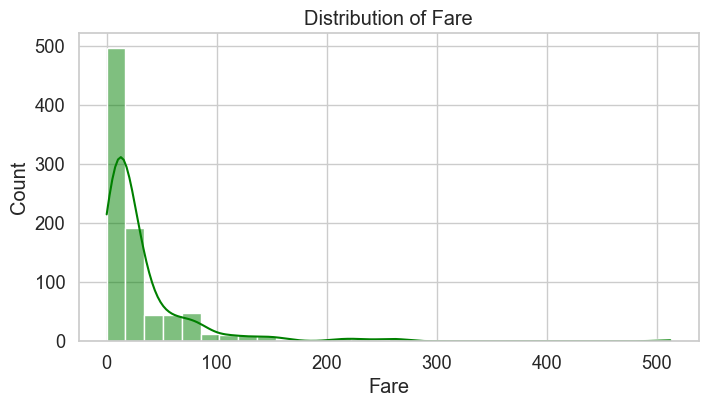

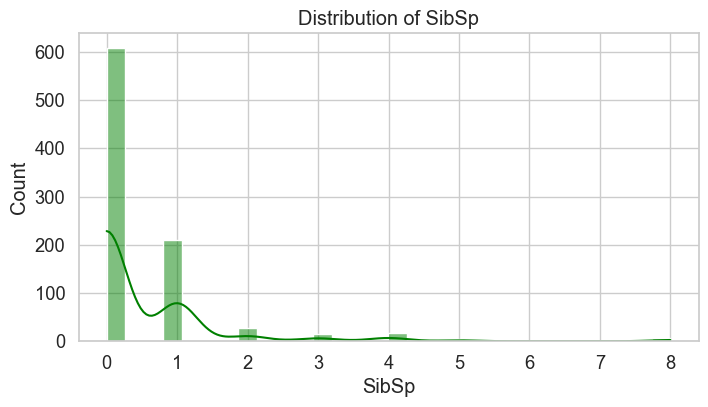

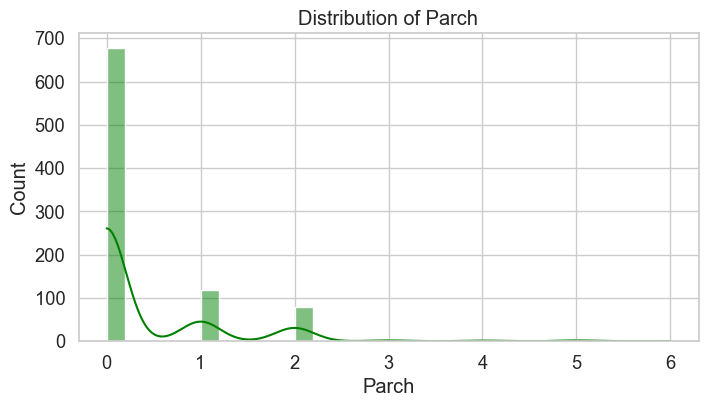

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# --------------------
# Numerical Features
# --------------------
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

for col in num_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True, color='green')
    plt.title(f"Distribution of {col}")
    plt.show()

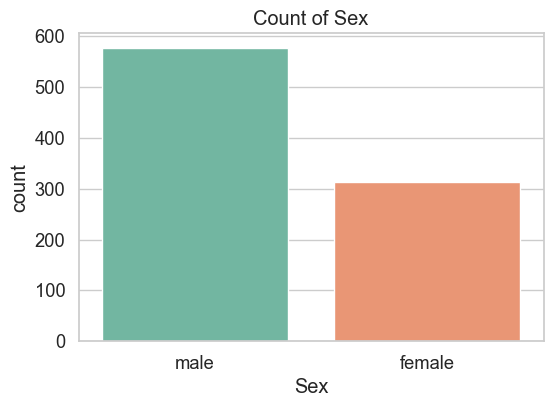

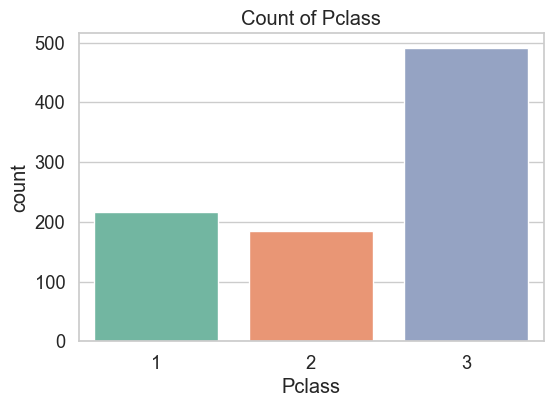

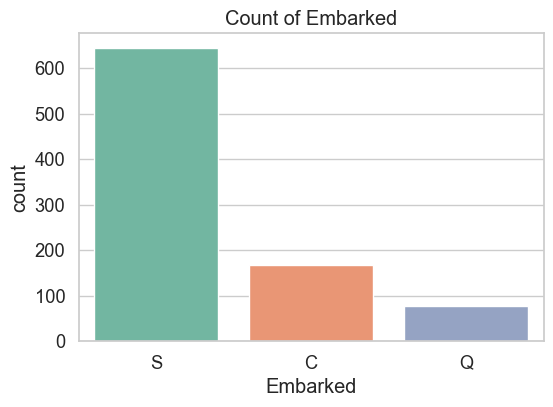

In [18]:
cat_features = ['Sex', 'Pclass', 'Embarked']

for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f"Count of {col}")
    plt.show()


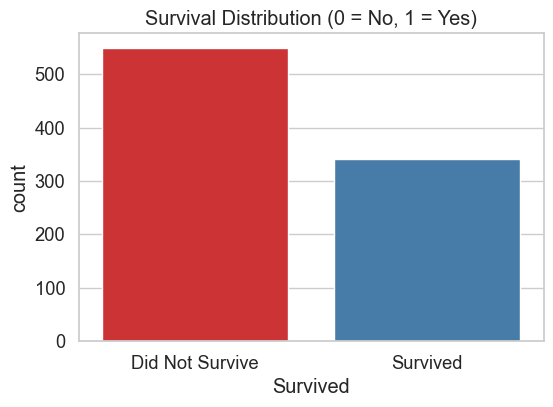

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived', palette="Set1")
plt.title("Survival Distribution (0 = No, 1 = Yes)")
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.show()

In [20]:
survival_rate = df['Survived'].value_counts(normalize=True) * 100
print("Survival Rate (%):")
print(survival_rate.round(2))

Survival Rate (%):
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


# Bivariate Analysis


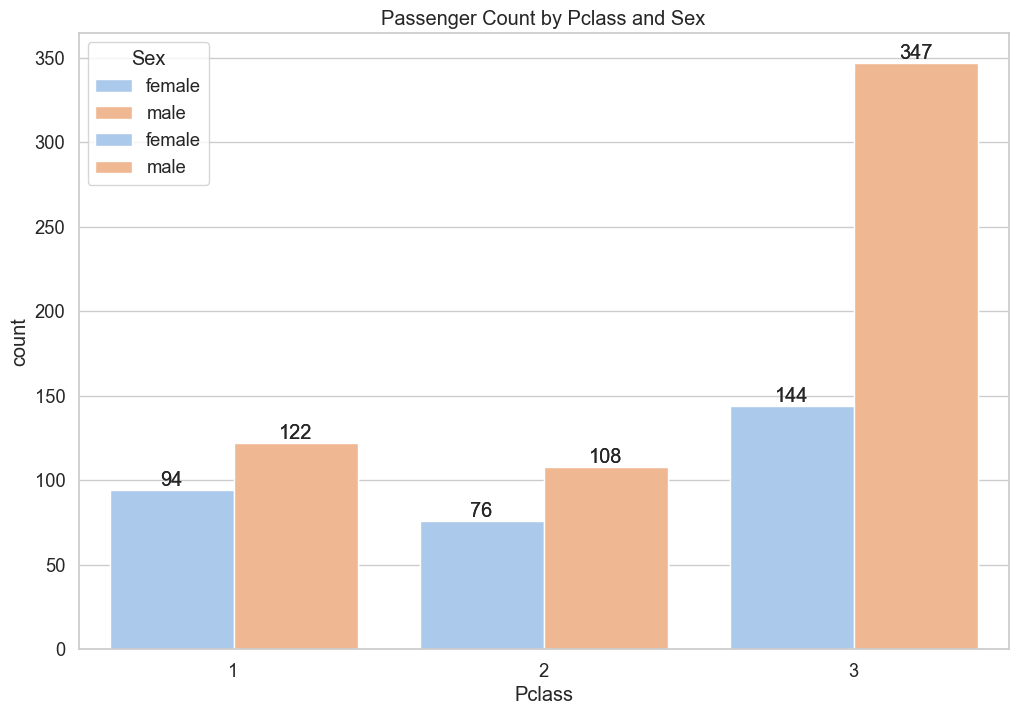

In [21]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='Pclass', hue='Sex', data=df, palette='pastel')
ax = sns.countplot(x='Pclass', hue='Sex', data=df, palette='pastel')
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Passenger Count by Pclass and Sex')
plt.show()

<Axes: xlabel='Survived', ylabel='Percentage'>

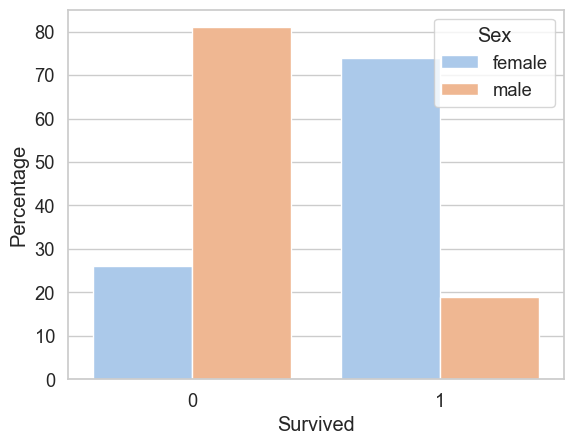

In [22]:
total_male = int(df["Sex"].value_counts()["male"]) 
total_female = int(df["Sex"].value_counts()["female"])
#print(type(int(total_male)))
df_sex_survival = df.groupby(["Sex",'Survived']).size().reset_index(name = "count")
def calct_percentage(row):
    return round(row['count']/total_male*100 if row['Sex'] == 'male' else row['count']/total_female*100, 0)

df_sex_survival["Percentage"] =df_sex_survival.apply(calct_percentage,axis = 1)

sns.barplot(data=df_sex_survival, x='Survived', y='Percentage', hue='Sex')

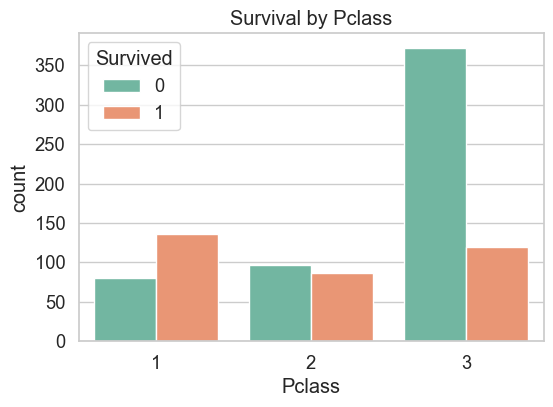

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title("Survival by Pclass")
plt.show()


--- Analysis: Survival by Pclass and Sex ---


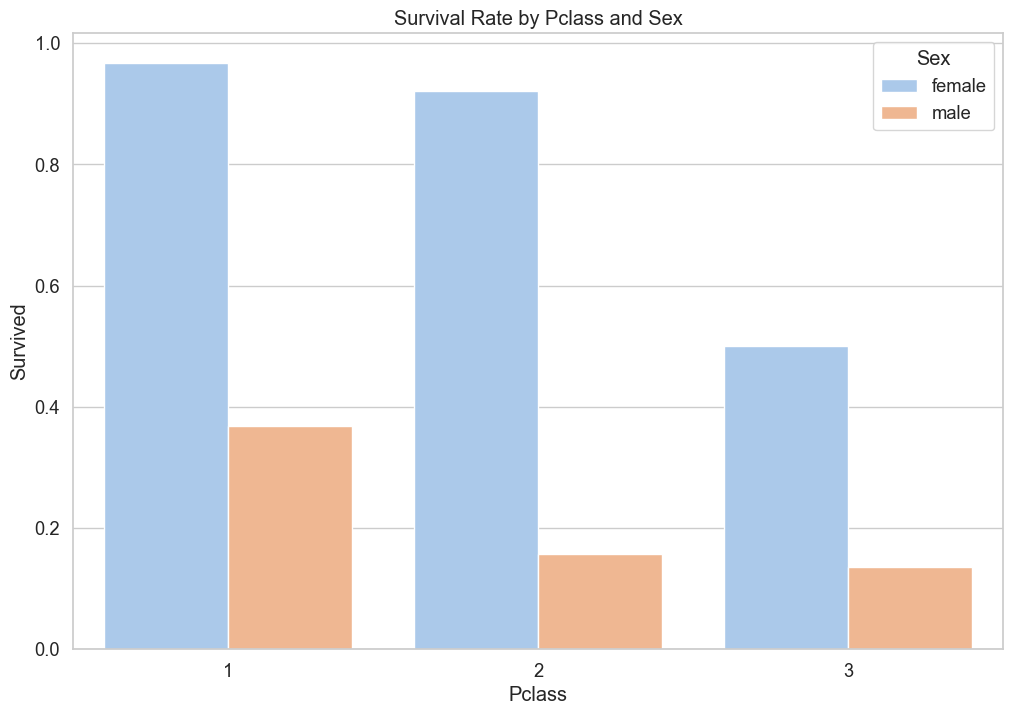

In [24]:
print("--- Analysis: Survival by Pclass and Sex ---")
# Create a grouped bar chart for survival rates
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='pastel', ci=None)
ax.set_title('Survival Rate by Pclass and Sex')
plt.show()

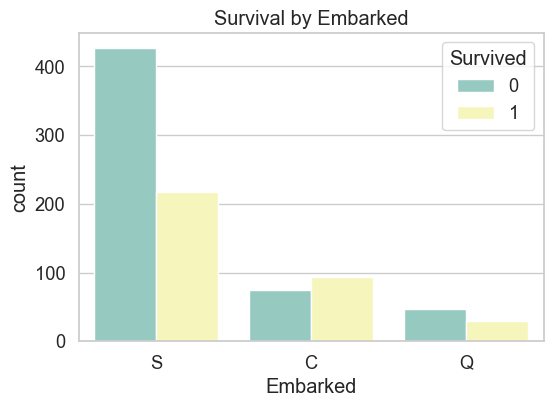

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Embarked', hue='Survived', palette='Set3')
plt.title("Survival by Embarked")
plt.show()

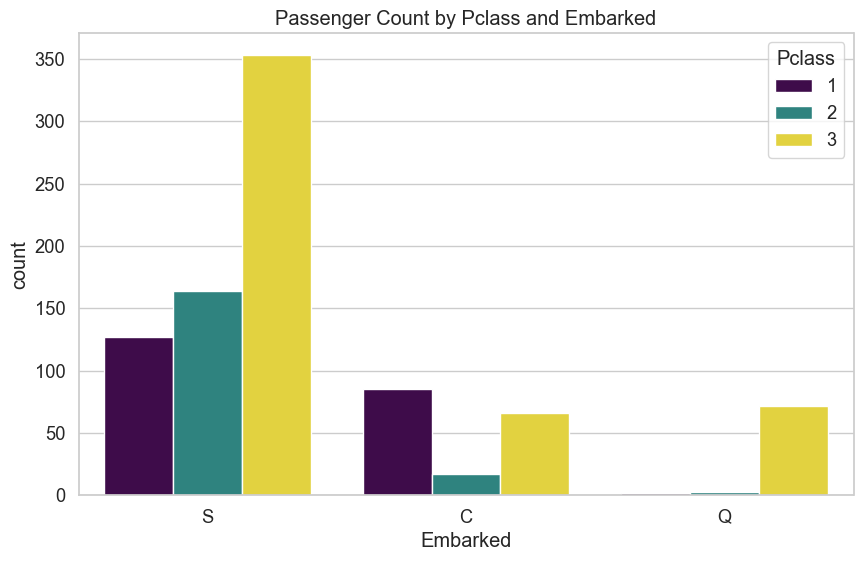

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Embarked', hue='Pclass', data=df, palette='viridis')
ax.set_title('Passenger Count by Pclass and Embarked')
plt.show()

--- Analysis: Relationship between Fare, Pclass, and Survival ---


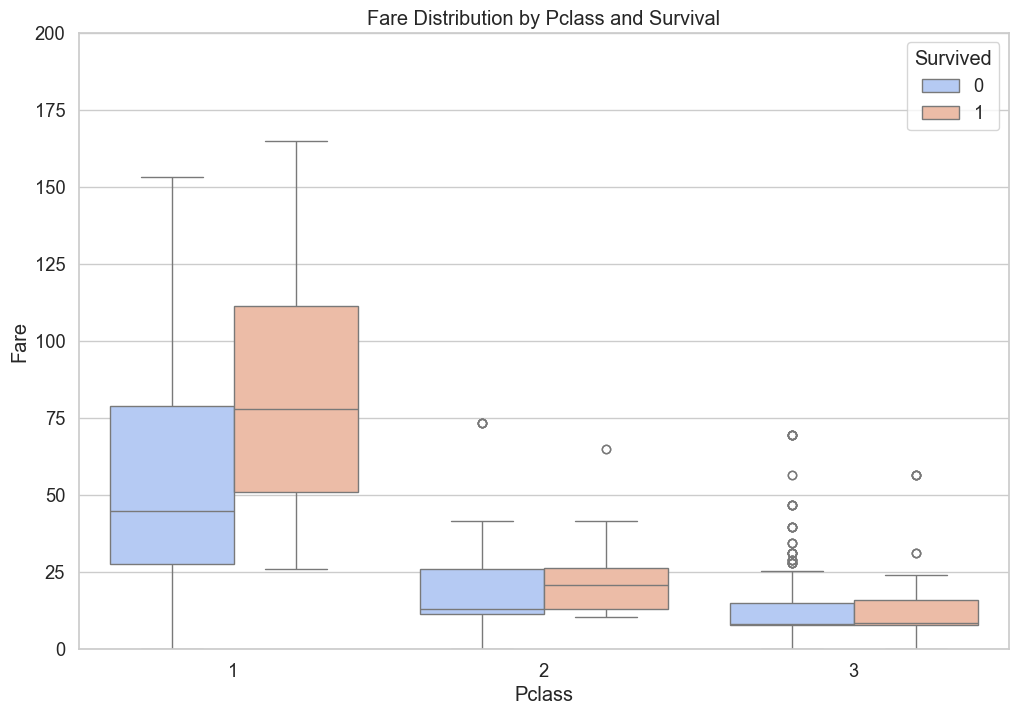

In [27]:
print("--- Analysis: Relationship between Fare, Pclass, and Survival ---")
# Plotting the relationship using box plots
plt.figure(figsize=(12, 8))
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df, palette='coolwarm')
plt.title('Fare Distribution by Pclass and Survival')
plt.ylim(0, 200) # Set a limit to improve visualization for the outliers
plt.show()

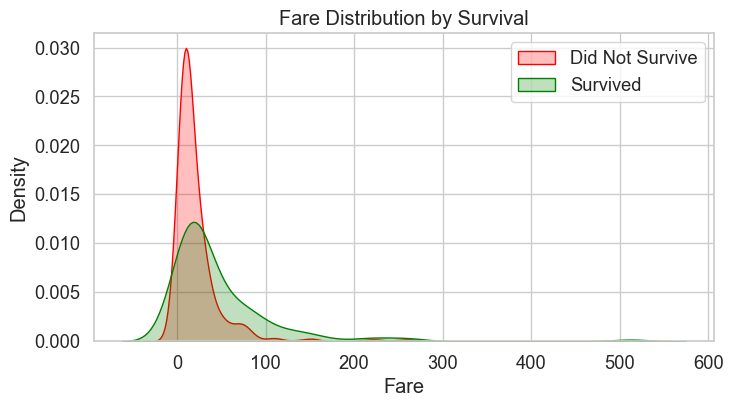

In [28]:
plt.figure(figsize=(8,4))
sns.kdeplot(df[df['Survived']==0]['Fare'], shade=True, label='Did Not Survive', color='red')
sns.kdeplot(df[df['Survived']==1]['Fare'], shade=True, label='Survived', color='green')
plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.legend()
plt.show()

--- Analysis: Scatter Plot of Fare vs. Age, Colored by Sex and Survival ---


<Axes: xlabel='Age', ylabel='Fare'>

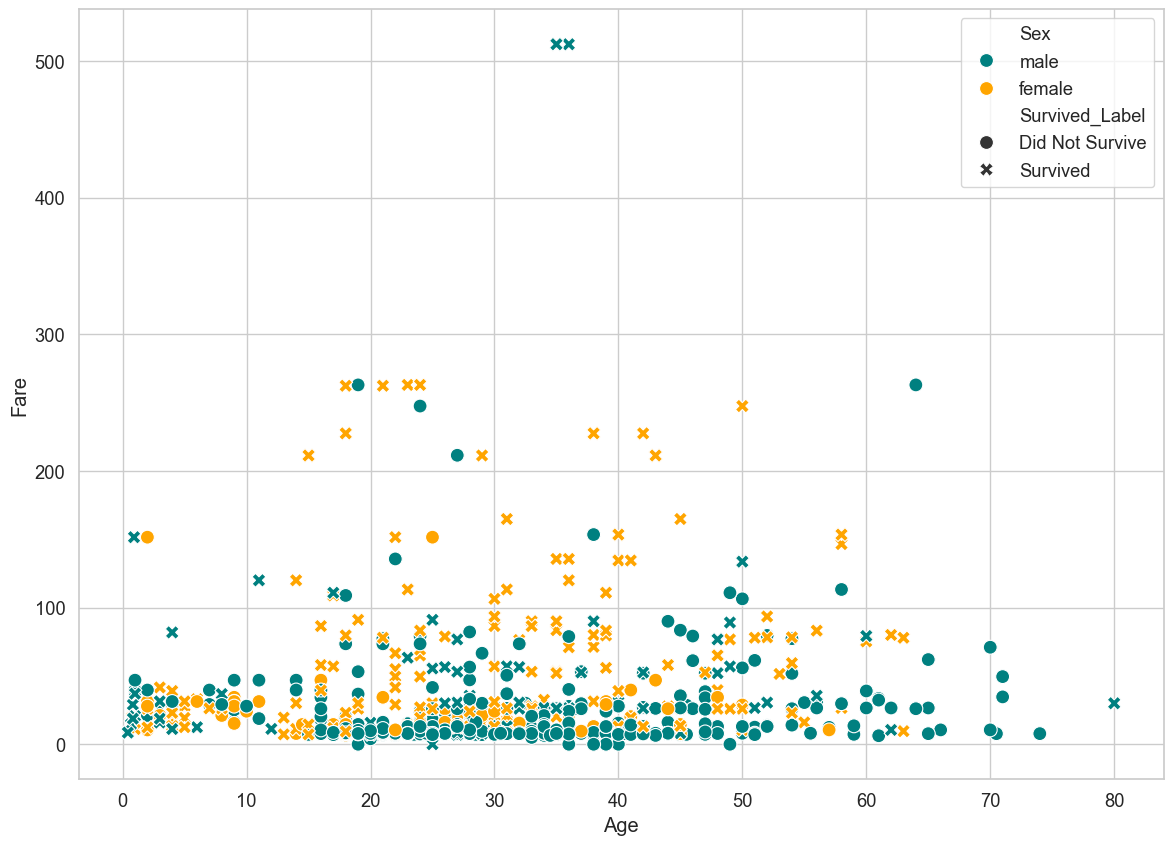

In [29]:
print("--- Analysis: Scatter Plot of Fare vs. Age, Colored by Sex and Survival ---")

# Replace 'Survived' with categorical labels for better readability in the legend
df['Survived_Label'] = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

# Create the scatter plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Sex',
    style='Survived_Label',
    palette={'male': 'teal', 'female': 'orange'},
    s=100  # Set marker size
)

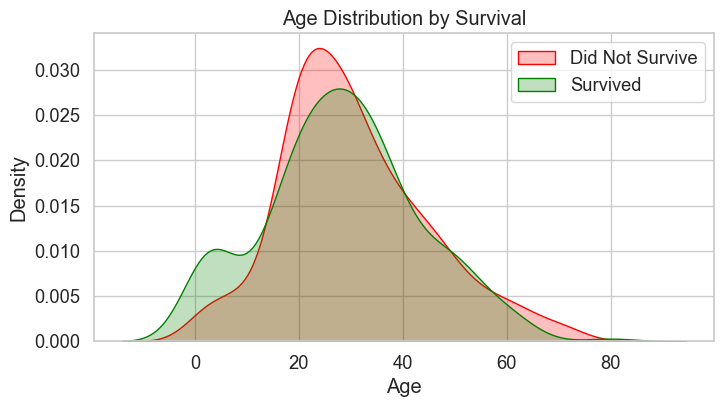

In [30]:
plt.figure(figsize=(8,4))
sns.kdeplot(df[df['Survived']==0]['Age'].dropna(), shade=True, label='Did Not Survive', color='red')
sns.kdeplot(df[df['Survived']==1]['Age'].dropna(), shade=True, label='Survived', color='green')
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.legend()
plt.show()

--- Analysis: Age Distribution by Pclass and Survival ---


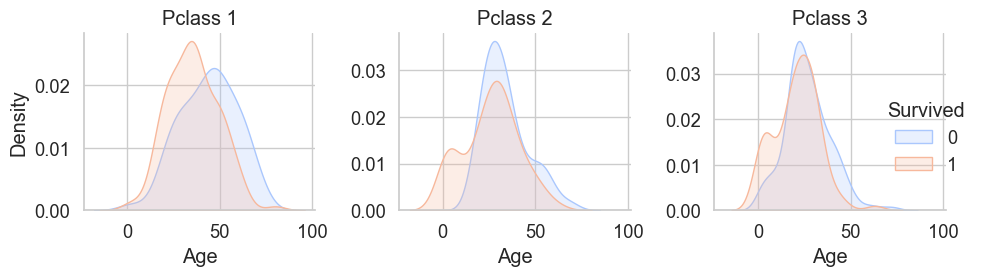

In [31]:
print("--- Analysis: Age Distribution by Pclass and Survival ---")

g = sns.FacetGrid(df, col='Pclass', hue='Survived', palette='coolwarm', sharex=True, sharey=False)
g.map(sns.kdeplot, 'Age', shade=True)
g.add_legend()
g.set_titles("Pclass {col_name}")
g.set_axis_labels("Age", "Density")
plt.tight_layout()
plt.show()


--- Analysis: Age Distribution by Sex and Survival ---


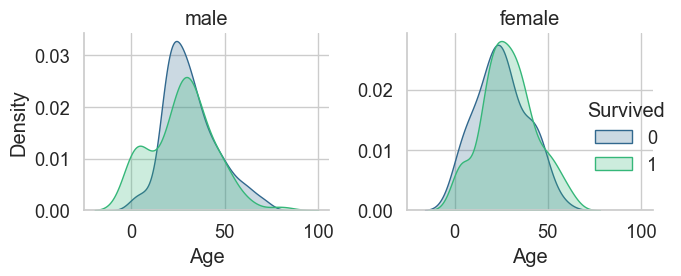

In [32]:
print("\n--- Analysis: Age Distribution by Sex and Survival ---")

g = sns.FacetGrid(df, col='Sex', hue='Survived', palette='viridis', sharex=True, sharey=False)
g.map(sns.kdeplot, 'Age', shade=True)
g.add_legend()
g.set_titles("{col_name}")
g.set_axis_labels("Age", "Density")
plt.tight_layout()
plt.show()